# Stage 7 — Remove building_id, Add sub_primaryspaceusage

Ablation variant of Stage 4b testing generalisability to unseen buildings.

**Changes vs Stage 4b:**
- `building_id` removed — was the #1 feature but breaks on new buildings (unseen category)
- `sub_primaryspaceusage` added — finer-grained building type from metadata (e.g. `Research`, `Residence Hall`)
- `sub_primaryspaceusage` merged directly from `metadata.csv` here (Stage 2 parquet does not include it)
- NaN `sub_primaryspaceusage` filled with `primaryspaceusage` as fallback before encoding

**Baseline (Stage 4b) to beat:**
- Test RMSE : 17.732 kWh
- Test MAE  : 5.914 kWh

In [1]:
import gc
import time
import warnings
from pathlib import Path
import os

import mlflow
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from dotenv import find_dotenv, load_dotenv
from IPython.display import display
from sklearn.metrics import mean_absolute_error, mean_squared_error

warnings.filterwarnings('ignore')
load_dotenv(find_dotenv())

sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams.update({'figure.dpi': 100, 'axes.titlesize': 13, 'axes.labelsize': 11})

OUTPUTS_DIR   = Path('../../data/processed/anomaly-detection')
RAW_DIR       = Path('../../data/raw/data')
FEATURES_PATH = OUTPUTS_DIR / 'stage2_features.parquet'
WEATHER_PATH  = RAW_DIR / 'weather' / 'weather.csv'
META_PATH     = RAW_DIR / 'metadata' / 'metadata.csv'
STAGE7_MODEL_OUT       = OUTPUTS_DIR / 'stage7_lgbm_model.txt'
STAGE7_RESID_STATS_OUT = OUTPUTS_DIR / 'stage7_resid_stats.parquet'
STAGE7_ANOMALIES_OUT   = OUTPUTS_DIR / 'stage7_anomalies.parquet'

TARGET_COL   = 'consumption'
RANDOM_STATE = 42
TEST_START   = pd.Timestamp('2017-11-01 00:00:00')

MLFLOW_TRACKING_URI = os.getenv('MLFLOW_TRACKING_URI', 'http://localhost:5000')
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment('stage7_no_building_id')

<Experiment: artifact_location='/mlflow/artifacts/2', creation_time=1782196692285, effective_trace_archival_retention=None, experiment_id='2', last_update_time=1782196692285, lifecycle_stage='active', name='stage7_no_building_id', tags={}, trace_location=None, workspace='default'>

---
## 1. Load Stage 2 Feature Matrix

In [2]:
df = pd.read_parquet(FEATURES_PATH)
df['timestamp'] = pd.to_datetime(df['timestamp'])
df.sort_values(['timestamp', 'building_id'], inplace=True)
df.reset_index(drop=True, inplace=True)

df_clean = df.dropna(subset=[TARGET_COL]).copy()

print(f'Raw rows               : {len(df):,}')
print(f'Rows with target        : {len(df_clean):,}')
print(f'Buildings               : {df_clean["building_id"].nunique():,}')
print(f'Date range              : {df_clean["timestamp"].min()} -> {df_clean["timestamp"].max()}')

Raw rows               : 27,684,432
Rows with target        : 24,635,328
Buildings               : 1,572
Date range              : 2016-01-01 00:00:00 -> 2017-12-31 23:00:00


### 1b. Merge sub_primaryspaceusage from metadata

Stage 2 does not include `sub_primaryspaceusage`; we join it directly here.
Buildings with a null value (no sub-category recorded) are filled with `primaryspaceusage`
so the model always has a valid category — no extra NaN bin needed.

In [3]:
meta = pd.read_csv(META_PATH, usecols=['building_id', 'sub_primaryspaceusage'])
meta['sub_primaryspaceusage'] = meta['sub_primaryspaceusage'].astype(str).str.strip()
meta['sub_primaryspaceusage'] = meta['sub_primaryspaceusage'].replace({'nan': None, '': None})

df_clean = df_clean.merge(meta, on='building_id', how='left')

# Fallback: fill missing sub-category with primaryspaceusage so no NaN in categorical
null_mask = df_clean['sub_primaryspaceusage'].isna()
df_clean.loc[null_mask, 'sub_primaryspaceusage'] = df_clean.loc[null_mask, 'primaryspaceusage']

n_null_before = null_mask.sum()
n_null_after  = df_clean['sub_primaryspaceusage'].isna().sum()
print(f'sub_primaryspaceusage null before fallback : {n_null_before:,}')
print(f'sub_primaryspaceusage null after fallback  : {n_null_after:,}')
print(f'Unique sub_primaryspaceusage values        : {df_clean["sub_primaryspaceusage"].nunique()}')
display(df_clean['sub_primaryspaceusage'].value_counts().head(20))

sub_primaryspaceusage null before fallback : 159,021
sub_primaryspaceusage null after fallback  : 159,021
Unique sub_primaryspaceusage values        : 103


sub_primaryspaceusage
Office                         4697286
College Classroom              2186137
College Laboratory             1896296
K-12 School                    1648088
Dormitory                      1531833
Education                      1139939
Primary/Secondary Classroom    1091534
Library                         856051
Other - Recreation              700373
Fire Station                    557045
Research                        458683
Classroom                       391990
Residence Hall                  382673
Other                           327766
Other - Public Services         327123
Community Center                306691
Police Station                  270277
Academic                        245509
Sports Stadium                  236530
Fitness Center                  204462
Name: count, dtype: int64

In [4]:
df_clean.sort_values(['building_id', 'timestamp'], inplace=True)
df_clean['rolling_mean_6h'] = (
    df_clean.groupby('building_id')['consumption']
    .transform(lambda s: s.shift(1).rolling(6, min_periods=1).mean())
    .astype('float32')
)
df_clean.sort_values(['timestamp', 'building_id'], inplace=True)
df_clean.reset_index(drop=True, inplace=True)
print(f'rolling_mean_6h missing rate: {df_clean["rolling_mean_6h"].isna().mean():.4f}')

rolling_mean_6h missing rate: 0.0001


---
## 2. Weather Feature Join

In [5]:
def load_weather_features(path: Path) -> tuple[pd.DataFrame, list[str]]:
    weather = pd.read_csv(path)
    weather['timestamp'] = pd.to_datetime(weather['timestamp'])
    weather.sort_values(['site_id', 'timestamp'], inplace=True)
    weather.reset_index(drop=True, inplace=True)

    for col in ['airTemperature', 'dewTemperature', 'windSpeed']:
        if col in weather.columns:
            weather[col] = pd.to_numeric(weather[col], errors='coerce')

    if {'airTemperature', 'dewTemperature'}.issubset(weather.columns):
        weather['temp_dew_spread'] = weather['airTemperature'] - weather['dewTemperature']

    grp = weather.groupby('site_id', sort=False)['airTemperature']
    weather['airTemperature_roll24h']  = grp.transform(lambda s: s.rolling(24,  min_periods=1).mean())
    weather['airTemperature_roll168h'] = grp.transform(lambda s: s.rolling(168, min_periods=1).mean())

    weather_feature_cols = [
        c for c in ['airTemperature', 'windSpeed', 'temp_dew_spread',
                    'airTemperature_roll24h', 'airTemperature_roll168h']
        if c in weather.columns
    ]
    return weather[['timestamp', 'site_id'] + weather_feature_cols], weather_feature_cols


weather_df, WEATHER_FEATURES = load_weather_features(WEATHER_PATH)
print(f'Weather rows     : {len(weather_df):,}')
print(f'Weather features : {WEATHER_FEATURES}')

df_clean = df_clean.merge(weather_df, on=['timestamp', 'site_id'], how='left')
missing_weather = df_clean[WEATHER_FEATURES].isna().mean().sort_values(ascending=False)
display(missing_weather.rename('missing_rate').to_frame())

Weather rows     : 331,166
Weather features : ['airTemperature', 'windSpeed', 'temp_dew_spread', 'airTemperature_roll24h', 'airTemperature_roll168h']


,missing_rate
windSpeed,0.005322
temp_dew_spread,0.004135
airTemperature,0.003750
airTemperature_roll24h,0.003412
airTemperature_roll168h,0.003412


---
## 2b. Holiday Features

In [6]:
import holidays as holidays_lib

TIMEZONE_TO_COUNTRY = {
    'US/Pacific':    'US',
    'US/Mountain':   'US',
    'US/Central':    'US',
    'US/Eastern':    'US',
    'Europe/London': 'GB',
    'Europe/Dublin': 'IE',
}
HOLIDAY_MAX_DAYS = 3


def build_holiday_lookup(df: pd.DataFrame, years: list) -> pd.DataFrame:
    site_tz = (
        df[['site_id', 'timezone']]
        .drop_duplicates()
        .set_index('site_id')['timezone']
        .to_dict()
    )
    records = []
    for site, tz in site_tz.items():
        country = TIMEZONE_TO_COUNTRY.get(tz)
        if country is None:
            continue
        cal = holidays_lib.country_holidays(country, years=years)
        for date in cal.keys():
            records.append({'site_id': site, 'date': pd.Timestamp(date)})
    return pd.DataFrame(records) if records else pd.DataFrame(columns=['site_id', 'date'])


def add_holiday_features(df: pd.DataFrame, holiday_lookup: pd.DataFrame, max_days: int = HOLIDAY_MAX_DAYS) -> None:
    base = pd.DataFrame({
        'site_id': df['site_id'].values,
        'date':    df['timestamp'].dt.normalize().values,
    })
    hl = holiday_lookup.assign(is_holiday=np.int8(1))
    df['is_holiday'] = (
        base.merge(hl, on=['site_id', 'date'], how='left')['is_holiday']
        .fillna(0).astype('int8').values
    )
    days_to   = np.full(len(df), max_days, dtype='int8')
    days_from = np.full(len(df), max_days, dtype='int8')
    for d in range(max_days, 0, -1):
        sb = holiday_lookup[['site_id', 'date']].copy()
        sb['date'] -= pd.Timedelta(days=d)
        sb = sb.drop_duplicates().assign(v=np.int8(1))
        days_to[base.merge(sb, on=['site_id', 'date'], how='left')['v'].notna().values] = d

        sf = holiday_lookup[['site_id', 'date']].copy()
        sf['date'] += pd.Timedelta(days=d)
        sf = sf.drop_duplicates().assign(v=np.int8(1))
        days_from[base.merge(sf, on=['site_id', 'date'], how='left')['v'].notna().values] = d

    df['days_to_next_holiday']    = days_to
    df['days_from_last_holiday']  = days_from


holiday_lookup = build_holiday_lookup(df_clean, years=[2016, 2017])
add_holiday_features(df_clean, holiday_lookup)

print(f"is_holiday           : {df_clean['is_holiday'].sum():,}  ({df_clean['is_holiday'].mean() * 100:.1f}%)")

is_holiday           : 743,326  (3.0%)


---
## 3. Feature Selection

Key changes from Stage 4b:
- `building_id` **removed** — unseen-category problem for new buildings; signal already carried by lag/rolling features
- `sub_primaryspaceusage` **added** — finer building-type grouping that generalises to new buildings

In [7]:
DIRECT_LEAKAGE_COLS = {
    'delta_1h', 'delta_24h', 'pct_change_1h', 'pct_change_24h', 'consumption_per_sqm',
}
FULL_HISTORY_REFERENCE_COLS = {
    'building_mean', 'building_median', 'building_std', 'building_p95', 'building_p99',
}

# building_id removed; sub_primaryspaceusage added
CAT_FEATURES = ['site_id', 'primaryspaceusage', 'sub_primaryspaceusage']

BASE_CANDIDATE_FEATURES = [
    # Calendar
    'hour', 'day_of_week', 'month',
    'day_of_year', 'week_of_year',
    'is_holiday', 'days_to_next_holiday', 'days_from_last_holiday',
    # Lag features
    'lag_1h', 'lag_24h', 'lag_168h',
    # Rolling features
    'rolling_mean_6h', 'rolling_mean_24h', 'rolling_std_24h',
    'rolling_mean_168h', 'rolling_std_168h',
    # Historical baseline features
    'historical_hour_median', 'historical_hour_std',
    'historical_hour_daytype_median',
    # Numeric metadata
    'sqm',
    # Categorical metadata  (building_id intentionally absent)
    'site_id', 'primaryspaceusage', 'sub_primaryspaceusage',
]

EXCLUDED_COLS = DIRECT_LEAKAGE_COLS | FULL_HISTORY_REFERENCE_COLS
candidate_features = BASE_CANDIDATE_FEATURES + WEATHER_FEATURES
FEATURE_COLS  = [c for c in candidate_features if c in df_clean.columns and c not in EXCLUDED_COLS]
CAT_PRESENT   = [c for c in CAT_FEATURES if c in FEATURE_COLS]

for col in CAT_PRESENT:
    df_clean[col] = df_clean[col].astype('category')

selected_non_target_cols = [c for c in ['timestamp'] + FEATURE_COLS if c != TARGET_COL]
int64_cols   = df_clean[selected_non_target_cols].select_dtypes(include=['int64']).columns.tolist()
float64_cols = df_clean[selected_non_target_cols].select_dtypes(include=['float64']).columns.tolist()
df_clean[int64_cols]   = df_clean[int64_cols].astype('int32')
df_clean[float64_cols] = df_clean[float64_cols].astype('float32')

print(f'Total selected features : {len(FEATURE_COLS)}')
print(f'Categorical features    : {CAT_PRESENT}')
print(f'\nFeature list:')
for f in FEATURE_COLS:
    print(f'  {f}')

feature_quality = (
    df_clean[FEATURE_COLS]
    .isna()
    .mean()
    .sort_values(ascending=False)
    .rename('missing_rate')
    .to_frame()
)
display(feature_quality.head(10))

# building_id kept as metadata column for residual calibration and scoring — not passed to model
selected_dataset_cols = ['timestamp', 'building_id', TARGET_COL] + FEATURE_COLS
selected_dataset = df_clean[selected_dataset_cols].copy()
print(f'\nDataset shape: {selected_dataset.shape[0]:,} rows x {selected_dataset.shape[1]} columns')

del df, df_clean, weather_df
gc.collect()

Total selected features : 28
Categorical features    : ['site_id', 'primaryspaceusage', 'sub_primaryspaceusage']

Feature list:
  hour
  day_of_week
  month
  day_of_year
  week_of_year
  is_holiday
  days_to_next_holiday
  days_from_last_holiday
  lag_1h
  lag_24h
  lag_168h
  rolling_mean_6h
  rolling_mean_24h
  rolling_std_24h
  rolling_mean_168h
  rolling_std_168h
  historical_hour_median
  historical_hour_std
  historical_hour_daytype_median
  sqm
  site_id
  primaryspaceusage
  sub_primaryspaceusage
  airTemperature
  windSpeed
  temp_dew_spread
  airTemperature_roll24h
  airTemperature_roll168h


,missing_rate
lag_168h,0.025420
lag_24h,0.009469
primaryspaceusage,0.006455
sub_primaryspaceusage,0.006455
windSpeed,0.005322
temp_dew_spread,0.004135
airTemperature,0.003750
airTemperature_roll24h,0.003412
airTemperature_roll168h,0.003412
historical_hour_daytype_median,0.003058



Dataset shape: 24,635,328 rows x 31 columns


75

---
## 4. Time-Aware Validation Splits

In [8]:
FOLDS = [
    {'fold': 1, 'train_start': pd.Timestamp('2016-01-01'), 'train_end': pd.Timestamp('2016-12-31 23:00:00'),
     'val_start': pd.Timestamp('2017-01-01'), 'val_end': pd.Timestamp('2017-02-28 23:00:00')},
    {'fold': 2, 'train_start': pd.Timestamp('2016-01-01'), 'train_end': pd.Timestamp('2017-02-28 23:00:00'),
     'val_start': pd.Timestamp('2017-03-01'), 'val_end': pd.Timestamp('2017-04-30 23:00:00')},
    {'fold': 3, 'train_start': pd.Timestamp('2016-01-01'), 'train_end': pd.Timestamp('2017-04-30 23:00:00'),
     'val_start': pd.Timestamp('2017-05-01'), 'val_end': pd.Timestamp('2017-06-30 23:00:00')},
    {'fold': 4, 'train_start': pd.Timestamp('2016-01-01'), 'train_end': pd.Timestamp('2017-06-30 23:00:00'),
     'val_start': pd.Timestamp('2017-07-01'), 'val_end': pd.Timestamp('2017-08-31 23:00:00')},
    {'fold': 5, 'train_start': pd.Timestamp('2016-01-01'), 'train_end': pd.Timestamp('2017-08-31 23:00:00'),
     'val_start': pd.Timestamp('2017-09-01'), 'val_end': pd.Timestamp('2017-10-30 23:00:00')},
]


def split_by_dates(frame, train_start, train_end, val_start, val_end):
    train_mask = (frame['timestamp'] >= train_start) & (frame['timestamp'] <= train_end)
    val_mask   = (frame['timestamp'] >= val_start)   & (frame['timestamp'] <= val_end)
    return frame.loc[train_mask].copy(), frame.loc[val_mask].copy()


test_df = selected_dataset[selected_dataset['timestamp'] >= TEST_START].copy()
print(f'Final untouched test: {TEST_START.date()} -> {test_df["timestamp"].max().date()}  rows={len(test_df):,}')

fold_summary = []
for fold in FOLDS:
    tr, va = split_by_dates(selected_dataset, fold['train_start'], fold['train_end'], fold['val_start'], fold['val_end'])
    fold_summary.append({
        'fold':        fold['fold'],
        'train_rows':  len(tr),
        'val_rows':    len(va),
        'train_buildings': tr['site_id'].nunique(),  # site-level now
    })
display(pd.DataFrame(fold_summary))

Final untouched test: 2017-11-01 -> 2017-12-31  rows=2,031,624


,fold,train_rows,val_rows,train_buildings
0,1,12398945,2027477,18
1,2,14426422,2047103,19
2,3,16473525,1998037,19
3,4,18471562,2089058,19
4,5,20560620,2009870,19


---
## 5. LightGBM Training on Chronological Folds

Training until validation scores don't improve for 200 rounds
[250]	valid_0's rmse: 19.4009
[500]	valid_0's rmse: 18.8748
[750]	valid_0's rmse: 18.7042
[1000]	valid_0's rmse: 18.572
[1250]	valid_0's rmse: 18.4771
[1500]	valid_0's rmse: 18.3849
[1750]	valid_0's rmse: 18.3163
[2000]	valid_0's rmse: 18.251
[2250]	valid_0's rmse: 18.1917
[2500]	valid_0's rmse: 18.1428
[2750]	valid_0's rmse: 18.0891
[3000]	valid_0's rmse: 18.0548
[3250]	valid_0's rmse: 18.0307
[3500]	valid_0's rmse: 17.995
[3750]	valid_0's rmse: 17.9768
[4000]	valid_0's rmse: 17.9616
[4250]	valid_0's rmse: 17.9484
[4500]	valid_0's rmse: 17.9063
[4750]	valid_0's rmse: 17.9005
Early stopping, best iteration is:
[4790]	valid_0's rmse: 17.8985
Evaluated only: rmse
🏃 View run fold_1 at: http://localhost:5000/#/experiments/2/runs/099f0c53159c4383a2773b3e4a272b35
🧪 View experiment at: http://localhost:5000/#/experiments/2

Fold 1  RMSE=17.895  MAE=6.099  best_iter=4790  time=731s


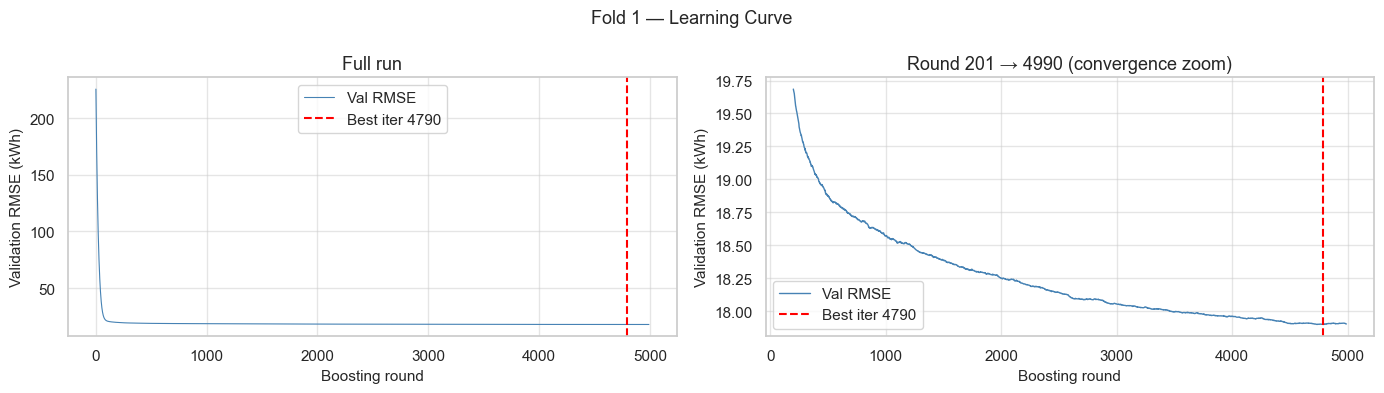

  Best iter 4790  |  Best val RMSE 17.8985  |  Final val RMSE 17.9024
Training until validation scores don't improve for 200 rounds
[250]	valid_0's rmse: 19.3672
[500]	valid_0's rmse: 18.9338
[750]	valid_0's rmse: 18.8209
[1000]	valid_0's rmse: 18.6656
[1250]	valid_0's rmse: 18.5756
[1500]	valid_0's rmse: 18.5005
[1750]	valid_0's rmse: 18.4664
[2000]	valid_0's rmse: 18.4207
[2250]	valid_0's rmse: 18.3874
[2500]	valid_0's rmse: 18.3757
[2750]	valid_0's rmse: 18.3534
[3000]	valid_0's rmse: 18.3395
Early stopping, best iteration is:
[3020]	valid_0's rmse: 18.3352
Evaluated only: rmse
🏃 View run fold_2 at: http://localhost:5000/#/experiments/2/runs/cd4c2b3f114d4750b385ea9dafd94a35
🧪 View experiment at: http://localhost:5000/#/experiments/2

Fold 2  RMSE=18.331  MAE=6.196  best_iter=3020  time=616s


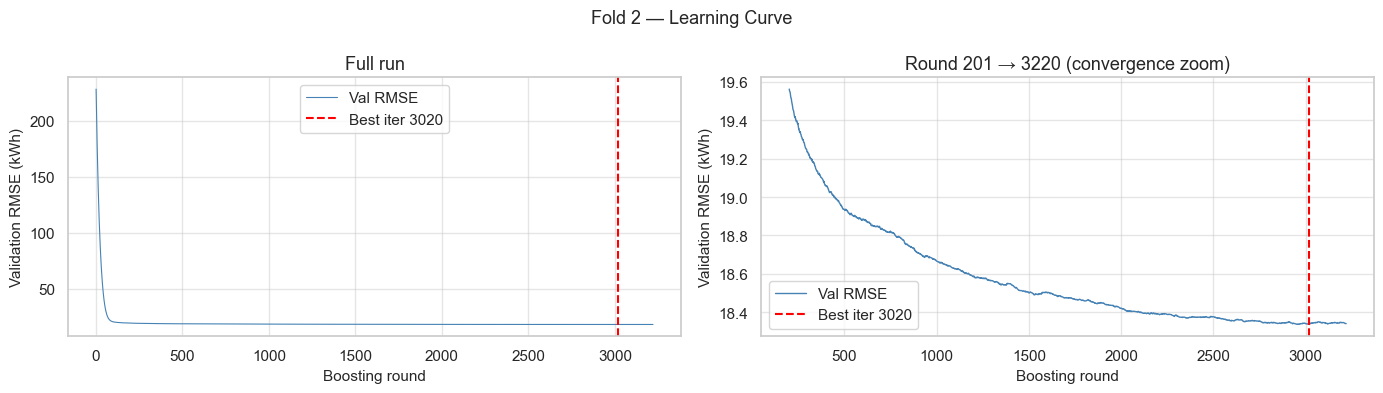

  Best iter 3020  |  Best val RMSE 18.3352  |  Final val RMSE 18.3399
Training until validation scores don't improve for 200 rounds
[250]	valid_0's rmse: 22.7212
[500]	valid_0's rmse: 22.042
[750]	valid_0's rmse: 21.7325
[1000]	valid_0's rmse: 21.5297
[1250]	valid_0's rmse: 21.3807
[1500]	valid_0's rmse: 21.2691
[1750]	valid_0's rmse: 21.195
[2000]	valid_0's rmse: 21.1355
[2250]	valid_0's rmse: 21.0816
[2500]	valid_0's rmse: 21.0275
[2750]	valid_0's rmse: 20.9894
[3000]	valid_0's rmse: 20.9559
[3250]	valid_0's rmse: 20.926
[3500]	valid_0's rmse: 20.9172
[3750]	valid_0's rmse: 20.8992
[4000]	valid_0's rmse: 20.8853
Early stopping, best iteration is:
[4045]	valid_0's rmse: 20.8792
Evaluated only: rmse
🏃 View run fold_3 at: http://localhost:5000/#/experiments/2/runs/f5edfe70f2004cd298ce1d92c9fbe95f
🧪 View experiment at: http://localhost:5000/#/experiments/2

Fold 3  RMSE=20.876  MAE=6.582  best_iter=4045  time=981s


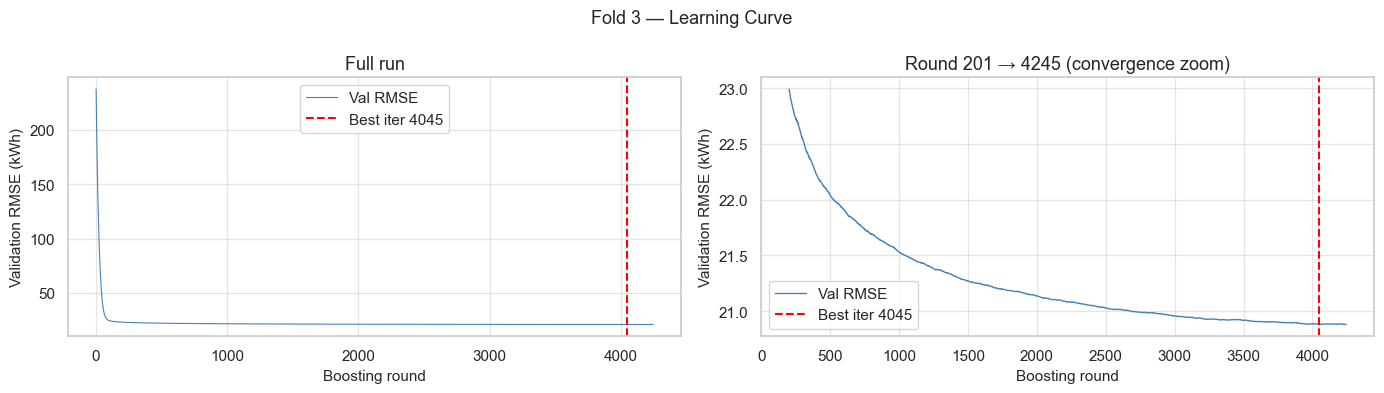

  Best iter 4045  |  Best val RMSE 20.8792  |  Final val RMSE 20.8816
Training until validation scores don't improve for 200 rounds
[250]	valid_0's rmse: 25.2193
[500]	valid_0's rmse: 24.4675
[750]	valid_0's rmse: 24.1309
[1000]	valid_0's rmse: 23.9166
[1250]	valid_0's rmse: 23.7655
[1500]	valid_0's rmse: 23.6427
[1750]	valid_0's rmse: 23.586
[2000]	valid_0's rmse: 23.5237
[2250]	valid_0's rmse: 23.4884
[2500]	valid_0's rmse: 23.4473
[2750]	valid_0's rmse: 23.4187
[3000]	valid_0's rmse: 23.4027
[3250]	valid_0's rmse: 23.3831
[3500]	valid_0's rmse: 23.3749
[3750]	valid_0's rmse: 23.3615
[4000]	valid_0's rmse: 23.3473
[4250]	valid_0's rmse: 23.3433
[4500]	valid_0's rmse: 23.3433
Early stopping, best iteration is:
[4348]	valid_0's rmse: 23.3329
Evaluated only: rmse
🏃 View run fold_4 at: http://localhost:5000/#/experiments/2/runs/e5ade98110854faf893de9d5064c0039
🧪 View experiment at: http://localhost:5000/#/experiments/2

Fold 4  RMSE=23.331  MAE=6.598  best_iter=4348  time=1092s


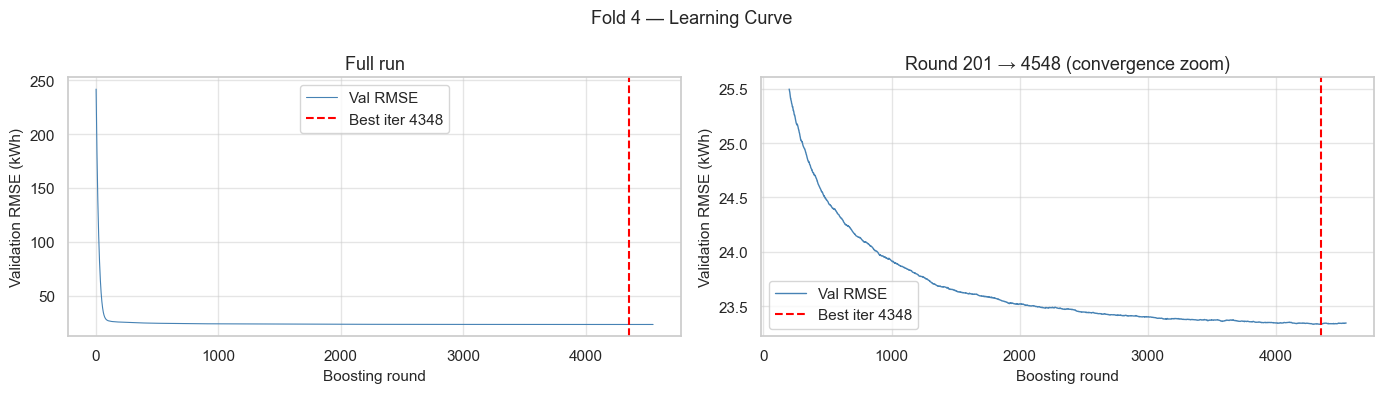

  Best iter 4348  |  Best val RMSE 23.3329  |  Final val RMSE 23.3462
Training until validation scores don't improve for 200 rounds
[250]	valid_0's rmse: 21.8037
[500]	valid_0's rmse: 20.9989
[750]	valid_0's rmse: 20.64
[1000]	valid_0's rmse: 20.4247
[1250]	valid_0's rmse: 20.2774
[1500]	valid_0's rmse: 20.1698
[1750]	valid_0's rmse: 20.0785
[2000]	valid_0's rmse: 20.01
[2250]	valid_0's rmse: 19.959
[2500]	valid_0's rmse: 19.9103
[2750]	valid_0's rmse: 19.8671
[3000]	valid_0's rmse: 19.8475
[3250]	valid_0's rmse: 19.8146
[3500]	valid_0's rmse: 19.8023
[3750]	valid_0's rmse: 19.7941
[4000]	valid_0's rmse: 19.7853
[4250]	valid_0's rmse: 19.7809
[4500]	valid_0's rmse: 19.7762
[4750]	valid_0's rmse: 19.7724
Early stopping, best iteration is:
[4600]	valid_0's rmse: 19.7684
Evaluated only: rmse
🏃 View run fold_5 at: http://localhost:5000/#/experiments/2/runs/f4a8d2b497f8413b992629e010b4ca9b
🧪 View experiment at: http://localhost:5000/#/experiments/2

Fold 5  RMSE=19.763  MAE=6.397  best_iter

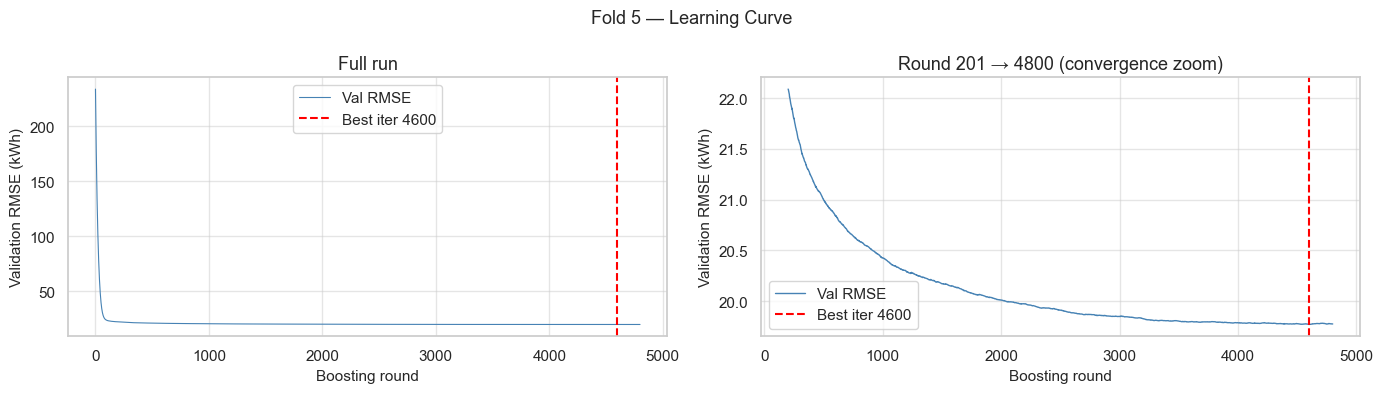

  Best iter 4600  |  Best val RMSE 19.7684  |  Final val RMSE 19.7737
🏃 View run stage7_no_building_id at: http://localhost:5000/#/experiments/2/runs/38dc8a45a2164df4bbd988d78afb6fb9
🧪 View experiment at: http://localhost:5000/#/experiments/2


,fold,val_rmse,val_mae,best_iteration,train_s
0,1,17.894859,6.099353,4790,731.103525
1,2,18.331366,6.196248,3020,615.517748
2,3,20.876193,6.581950,4045,980.646442
3,4,23.331155,6.598017,4348,1091.954781
4,5,19.763410,6.397447,4600,1297.620971


In [9]:
def rmse(y_true, y_pred) -> float:
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


BASE_LGB_PARAMS = {
    'objective':    'regression',
    'metric':       'rmse',
    'boosting_type':'gbdt',
    'n_estimators': 5000,
    'n_jobs':       18,
    'random_state': RANDOM_STATE,
    'verbose':      -1,
}

# Same hyperparameters as Stage 4b deeper_regularized_with_holidays_v2
BEST_PARAMS = {
    'candidate':        'stage7_no_building_id',
    'learning_rate':    0.04,
    'num_leaves':       511,
    'max_depth':        8,
    'min_child_samples':1500,
    'subsample':        0.85,
    'subsample_freq':   1,
    'colsample_bytree': 0.85,
    # 'reg_alpha':        2.0,
    'reg_lambda':       1.0,
}

EARLY_STOPPING_ROUNDS = 200


def train_eval_lgbm(train_frame, val_frame, params):
    model_params = {**BASE_LGB_PARAMS, **{k: v for k, v in params.items() if k != 'candidate'}}
    model = lgb.LGBMRegressor(**model_params)
    model.fit(
        train_frame[FEATURE_COLS], train_frame[TARGET_COL],
        eval_set=[(val_frame[FEATURE_COLS], val_frame[TARGET_COL])],
        eval_metric='rmse',
        categorical_feature=CAT_PRESENT,
        callbacks=[
            lgb.early_stopping(EARLY_STOPPING_ROUNDS, first_metric_only=True, verbose=True),
            lgb.log_evaluation(250),
        ],
    )
    pred = model.predict(val_frame[FEATURE_COLS]).clip(min=0)
    return model, {
        'rmse':           rmse(val_frame[TARGET_COL], pred),
        'mae':            mean_absolute_error(val_frame[TARGET_COL], pred),
        'best_iteration': model.best_iteration_,
    }


def plot_fold_learning_curve(model, fold_num):
    val_rmse  = model.evals_result_['valid_0']['rmse']
    rounds    = range(1, len(val_rmse) + 1)
    best_iter = model.best_iteration_
    zoom_start = 200

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    fig.suptitle(f'Fold {fold_num} — Learning Curve', fontsize=13)

    axes[0].plot(rounds, val_rmse, color='steelblue', linewidth=0.8, label='Val RMSE')
    axes[0].axvline(best_iter, color='red', linestyle='--', linewidth=1.5, label=f'Best iter {best_iter}')
    axes[0].set_title('Full run')
    axes[0].set_xlabel('Boosting round')
    axes[0].set_ylabel('Validation RMSE (kWh)')
    axes[0].legend()

    axes[1].plot(list(rounds)[zoom_start:], val_rmse[zoom_start:], color='steelblue', linewidth=1.0, label='Val RMSE')
    axes[1].axvline(best_iter, color='red', linestyle='--', linewidth=1.5, label=f'Best iter {best_iter}')
    axes[1].set_title(f'Round {zoom_start + 1} → {len(val_rmse)} (convergence zoom)')
    axes[1].set_xlabel('Boosting round')
    axes[1].set_ylabel('Validation RMSE (kWh)')
    axes[1].legend()

    plt.tight_layout()
    plt.show()
    print(f'  Best iter {best_iter}  |  Best val RMSE {val_rmse[best_iter - 1]:.4f}  |  Final val RMSE {val_rmse[-1]:.4f}')


tuning_rows = []
with mlflow.start_run(run_name=BEST_PARAMS['candidate']):
    mlflow.log_params({k: v for k, v in BEST_PARAMS.items() if k != 'candidate'})
    mlflow.log_params({'n_features': len(FEATURE_COLS), 'removed': 'building_id', 'added': 'sub_primaryspaceusage'})

    for fold in FOLDS:
        tr, va = split_by_dates(selected_dataset, fold['train_start'], fold['train_end'], fold['val_start'], fold['val_end'])
        t0 = time.time()
        model, metrics = train_eval_lgbm(tr, va, BEST_PARAMS)
        elapsed = time.time() - t0

        with mlflow.start_run(run_name=f'fold_{fold["fold"]}', nested=True):
            mlflow.log_metrics({'val_rmse': metrics['rmse'], 'val_mae': metrics['mae'], 'train_s': elapsed})

        tuning_rows.append({
            'fold': fold['fold'], 'val_rmse': metrics['rmse'],
            'val_mae': metrics['mae'], 'best_iteration': metrics['best_iteration'], 'train_s': elapsed,
        })
        print(f"\nFold {fold['fold']}  RMSE={metrics['rmse']:.3f}  MAE={metrics['mae']:.3f}  "
              f"best_iter={metrics['best_iteration']}  time={elapsed:.0f}s")
        plot_fold_learning_curve(model, fold['fold'])

tuning_df = pd.DataFrame(tuning_rows)
display(tuning_df)

---
## 6. Refit and Evaluate on Untouched Test Period

In [10]:
fit_df   = selected_dataset[selected_dataset['timestamp'] < TEST_START].copy()
test_df  = selected_dataset[selected_dataset['timestamp'] >= TEST_START].copy()

final_train = fit_df[fit_df['timestamp'] <= pd.Timestamp('2017-06-30 23:00:00')].copy()
final_valid = fit_df[(fit_df['timestamp'] >= pd.Timestamp('2017-07-01')) & (fit_df['timestamp'] < TEST_START)].copy()

final_params = {**BASE_LGB_PARAMS, **{k: v for k, v in BEST_PARAMS.items() if k != 'candidate'}}
early_stop_model = lgb.LGBMRegressor(**final_params)
early_stop_model.fit(
    final_train[FEATURE_COLS], final_train[TARGET_COL],
    eval_set=[(final_valid[FEATURE_COLS], final_valid[TARGET_COL])],
    eval_metric='rmse',
    categorical_feature=CAT_PRESENT,
    callbacks=[
        lgb.early_stopping(EARLY_STOPPING_ROUNDS, first_metric_only=True, verbose=True),
        lgb.log_evaluation(250),
    ],
)

selected_iteration = early_stop_model.best_iteration_ or final_params['n_estimators']
production_params  = {**final_params, 'n_estimators': selected_iteration}
final_model = lgb.LGBMRegressor(**production_params)
final_model.fit(fit_df[FEATURE_COLS], fit_df[TARGET_COL], categorical_feature=CAT_PRESENT)

test_pred = final_model.predict(test_df[FEATURE_COLS]).clip(min=0)
test_rmse = rmse(test_df[TARGET_COL], test_pred)
test_mae  = mean_absolute_error(test_df[TARGET_COL], test_pred)

print('=== Stage 7 Test Results ===')
print(f'Test RMSE      : {test_rmse:.3f} kWh')
print(f'Test MAE       : {test_mae:.3f} kWh')
print(f'Selected trees : {selected_iteration}')
print()
print('=== Stage 4b Baseline ===')
print('Test RMSE      : 17.732 kWh')
print('Test MAE       : 5.914 kWh')

final_model.booster_.save_model(str(STAGE7_MODEL_OUT))
print(f'\nModel saved → {STAGE7_MODEL_OUT}')

Training until validation scores don't improve for 200 rounds
[250]	valid_0's rmse: 24.2049
[500]	valid_0's rmse: 23.4472
[750]	valid_0's rmse: 23.122
[1000]	valid_0's rmse: 22.917
[1250]	valid_0's rmse: 22.7677
[1500]	valid_0's rmse: 22.6476
[1750]	valid_0's rmse: 22.5922
[2000]	valid_0's rmse: 22.5329
[2250]	valid_0's rmse: 22.4908
[2500]	valid_0's rmse: 22.4528
[2750]	valid_0's rmse: 22.4193
[3000]	valid_0's rmse: 22.4022
[3250]	valid_0's rmse: 22.3818
[3500]	valid_0's rmse: 22.3763
[3750]	valid_0's rmse: 22.3668
[4000]	valid_0's rmse: 22.3545
[4250]	valid_0's rmse: 22.3521
Early stopping, best iteration is:
[4291]	valid_0's rmse: 22.3461
Evaluated only: rmse
=== Stage 7 Test Results ===
Test RMSE      : 17.886 kWh
Test MAE       : 5.923 kWh
Selected trees : 4291

=== Stage 4b Baseline ===
Test RMSE      : 17.732 kWh
Test MAE       : 5.914 kWh

Model saved → ..\..\data\processed\anomaly-detection\stage7_lgbm_model.txt


---
## 7. Diagnostics — Feature Importance

Key question: is `lag_1h` / `rolling_mean_*` now the top feature instead of `building_id`?

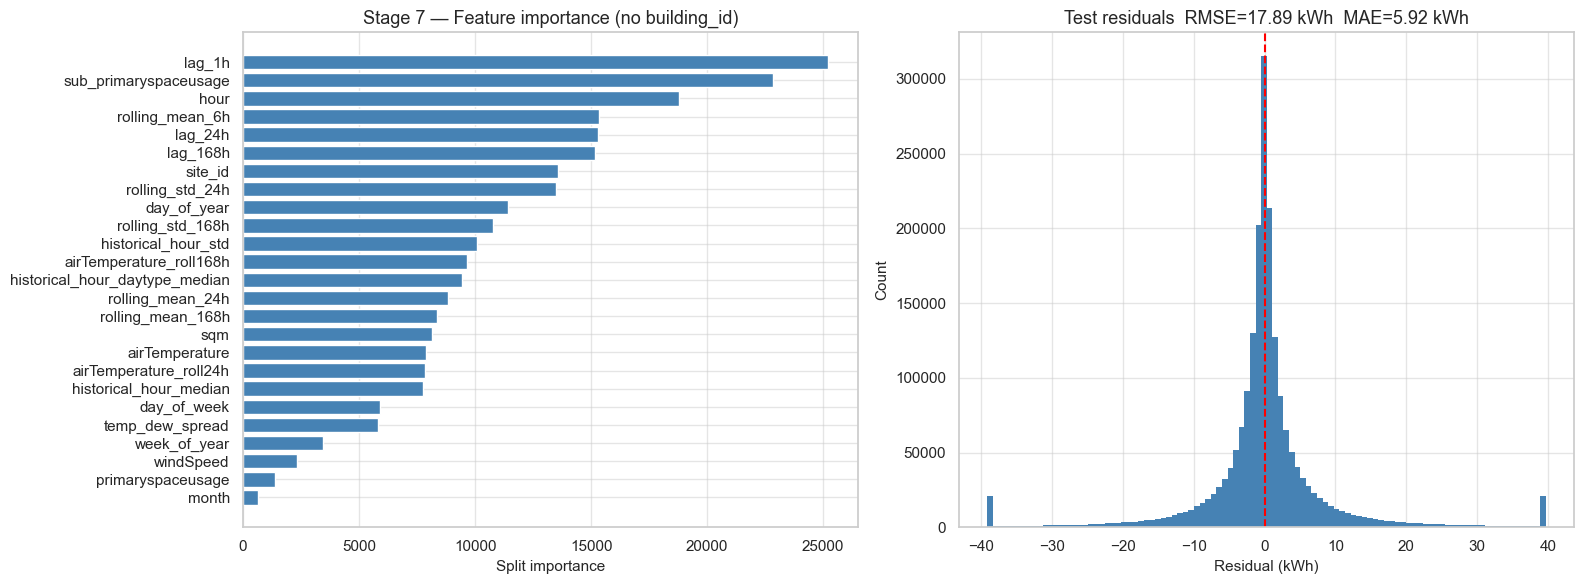

,feature,importance
0,lag_1h,25227
1,sub_primaryspaceusage,22833
2,hour,18782
3,rolling_mean_6h,15336
4,lag_24h,15310
5,lag_168h,15150
6,site_id,13584
7,rolling_std_24h,13504
8,day_of_year,11411
9,rolling_std_168h,10753


In [11]:
importance = (
    pd.DataFrame({
        'feature':    final_model.feature_name_,
        'importance': final_model.feature_importances_,
    })
    .sort_values('importance', ascending=False)
    .reset_index(drop=True)
)

resid_test = test_df[TARGET_COL].values - test_pred
lo, hi = np.percentile(resid_test, [1, 99])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top25 = importance.head(25)
axes[0].barh(top25['feature'][::-1], top25['importance'][::-1], color='steelblue')
axes[0].set_title('Stage 7 — Feature importance (no building_id)')
axes[0].set_xlabel('Split importance')

axes[1].hist(np.clip(resid_test, lo, hi), bins=100, color='steelblue', edgecolor='none')
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_title(f'Test residuals  RMSE={test_rmse:.2f} kWh  MAE={test_mae:.2f} kWh')
axes[1].set_xlabel('Residual (kWh)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

display(importance.head(30))

---
## 8. Residual Calibration (Out-of-Sample)

Same approach as Stage 4b.
Fallback for new buildings (absent from calibration window) uses `sub_primaryspaceusage`-group median
— finer-grained than the Stage 4b `primaryspaceusage` fallback.

In [12]:
ANOMALY_Z = 3.0

cal_pred  = early_stop_model.predict(final_valid[FEATURE_COLS]).clip(min=0)
cal_resid = pd.DataFrame({
    'building_id': final_valid['building_id'].values,
    'resid':       final_valid[TARGET_COL].values - cal_pred,
})

resid_stats = (
    cal_resid.groupby('building_id')['resid']
    .agg(
        resid_median='median',
        resid_mad=lambda x: np.median(np.abs(x - np.median(x))),
    )
    .reset_index()
)

# Fallback: use sub_primaryspaceusage-group median (finer than primaryspaceusage)
bld_meta = (
    test_df[['building_id', 'site_id', 'primaryspaceusage', 'sub_primaryspaceusage']]
    .drop_duplicates('building_id')
    .assign(
        primaryspaceusage=lambda d: d['primaryspaceusage'].astype(str),
        sub_primaryspaceusage=lambda d: d['sub_primaryspaceusage'].astype(str),
    )
)
resid_stats = bld_meta.merge(resid_stats, on='building_id', how='left')

nan_mask = resid_stats['resid_median'].isna()

# Try sub_primaryspaceusage first, then fall back to primaryspaceusage
group_fb_sub = (
    resid_stats.loc[~nan_mask]
    .groupby('sub_primaryspaceusage')[['resid_median', 'resid_mad']]
    .median()
    .rename(columns={'resid_median': 'fb_median_sub', 'resid_mad': 'fb_mad_sub'})
)
group_fb_psu = (
    resid_stats.loc[~nan_mask]
    .groupby('primaryspaceusage')[['resid_median', 'resid_mad']]
    .median()
    .rename(columns={'resid_median': 'fb_median_psu', 'resid_mad': 'fb_mad_psu'})
)

resid_stats = resid_stats.merge(group_fb_sub, on='sub_primaryspaceusage', how='left')
resid_stats = resid_stats.merge(group_fb_psu, on='primaryspaceusage', how='left')

resid_stats.loc[nan_mask, 'resid_median'] = resid_stats.loc[nan_mask, 'fb_median_sub'].fillna(
    resid_stats.loc[nan_mask, 'fb_median_psu']
)
resid_stats.loc[nan_mask, 'resid_mad'] = resid_stats.loc[nan_mask, 'fb_mad_sub'].fillna(
    resid_stats.loc[nan_mask, 'fb_mad_psu']
)
resid_stats = resid_stats.drop(columns=['fb_median_sub', 'fb_mad_sub', 'fb_median_psu', 'fb_mad_psu'])

print(f'Buildings calibrated (direct)  : {int((~nan_mask).sum()):,}')
print(f'Buildings on group fallback    : {int(nan_mask.sum())}')
print(f'Buildings with MAD = 0         : {int((resid_stats["resid_mad"] == 0).sum())}')
print(f'Buildings still NaN            : {int(resid_stats["resid_mad"].isna().sum())}')

resid_stats.to_parquet(STAGE7_RESID_STATS_OUT, index=False)
print(f'\nResid stats saved → {STAGE7_RESID_STATS_OUT}')

resid_stats = resid_stats.drop(columns=['site_id', 'primaryspaceusage', 'sub_primaryspaceusage'])

Buildings calibrated (direct)  : 1,409
Buildings on group fallback    : 30
Buildings with MAD = 0         : 0
Buildings still NaN            : 0

Resid stats saved → ..\..\data\processed\anomaly-detection\stage7_resid_stats.parquet


---
## 9. Anomaly Scoring on Test Period (Nov–Dec 2017)

In [13]:
score_df = test_df.copy()
score_df['predicted'] = test_pred
score_df['residual']  = score_df[TARGET_COL].values - score_df['predicted'].values

score_df = score_df.merge(resid_stats, on='building_id', how='left')

MAD_SCALE = 1.4826
MAD_FLOOR = 1e-3
safe_mad = (score_df['resid_mad'] * MAD_SCALE).clip(lower=MAD_FLOOR)
score_df['residual_z']   = (score_df['residual'] - score_df['resid_median']) / safe_mad
score_df['anomaly_score'] = score_df['residual_z'].abs()
score_df['is_anomaly']    = score_df['anomaly_score'] > ANOMALY_Z
score_df['direction'] = np.where(
    score_df['residual_z'] >  ANOMALY_Z, 'over',
    np.where(score_df['residual_z'] < -ANOMALY_Z, 'under', 'normal'),
)

SEV_THRESHOLDS = [(10.0, 'Critical'), (6.0, 'High'), (4.0, 'Medium'), (3.0, 'Low')]
score_df['severity'] = np.select(
    [score_df['anomaly_score'] >= t for t, _ in SEV_THRESHOLDS],
    [s for _, s in SEV_THRESHOLDS],
    default='normal',
)

n_total   = len(score_df)
n_anomaly = score_df['is_anomaly'].sum()
print(f'Scoring rows       : {n_total:,}')
print(f'Anomalies flagged  : {n_anomaly:,}  ({n_anomaly / n_total:.2%})')
print(f'  Over-consumption : {(score_df["direction"] == "over").sum():,}')
print(f'  Under-consumption: {(score_df["direction"] == "under").sum():,}')

sev_order = ['Critical', 'High', 'Medium', 'Low']
sev_counts = (
    score_df[score_df['is_anomaly']]['severity']
    .value_counts().reindex(sev_order).fillna(0).astype(int)
)
print('\nSeverity breakdown:')
for sev, cnt in sev_counts.items():
    print(f'  {sev:8s}: {cnt:,}  ({cnt / max(n_anomaly, 1):.1%})')

Scoring rows       : 2,031,624
Anomalies flagged  : 123,706  (6.09%)
  Over-consumption : 66,969
  Under-consumption: 56,737

Severity breakdown:
  Critical: 9,961  (8.1%)
  High    : 19,154  (15.5%)
  Medium  : 39,478  (31.9%)
  Low     : 55,113  (44.6%)


---
## 10. Export

In [14]:
keep_cols = ['building_id', 'timestamp', TARGET_COL, 'predicted', 'residual',
             'residual_z', 'anomaly_score', 'severity', 'direction', 'is_anomaly']
for extra in ['site_id', 'primaryspaceusage', 'sub_primaryspaceusage', 'sqm']:
    if extra in score_df.columns:
        keep_cols.append(extra)

out_df = score_df[keep_cols].copy()
out_df.to_parquet(STAGE7_ANOMALIES_OUT, index=False)

print(f'Exported → {STAGE7_ANOMALIES_OUT}')
print(f'Rows     : {len(out_df):,}')
print(f'Anomalies: {out_df["is_anomaly"].sum():,}  ({out_df["is_anomaly"].mean():.2%})')

Exported → ..\..\data\processed\anomaly-detection\stage7_anomalies.parquet
Rows     : 2,031,624
Anomalies: 123,706  (6.09%)
